# Model B: Otremba 2022 SmartPitch MLP

이 노트북은 **Model B (Otremba 2022)**의 구조, 데이터 처리 흐름, 학습 설정, 결과를 상세히 정리한다.

## 구성

1. 논문 개요
2. 아키텍처
3. 77차원 Feature 분해
4. 데이터 처리 흐름
5. 4-class 라벨 분포
6. 모델 코드 Walkthrough
7. 학습 설정
8. 결과
9. Sample Prediction
10. 한계점

In [1]:
# 라이브러리 import 및 환경 설정
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 프로젝트 루트를 sys.path에 추가 (src/ import 위해)
sys.path.insert(0, str(Path('..').resolve()))

from src.models.otremba_mlp import OtrembaMLP
from src.data.features import PitchResult4

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('환경 설정 완료')
print(f'PyTorch: {torch.__version__}')

환경 설정 완료
PyTorch: 2.6.0+cu124


## 1. 논문 개요

### 1.1 기본 정보

| 항목 | 내용 |
|------|------|
| 제목 | SmartPitch: Leveraging Statcast Data for Pitch Outcome Prediction |
| 저자 | Otremba |
| 출판 | 2022 |
| 데이터 | MLB Statcast |

### 1.2 핵심 아이디어

Statcast의 투구 물리량(구속, 회전수, 무브먼트, 위치 등)을
**77차원 벡터**로 표현하여 **2-layer MLP**로 투구 결과(4-class)를 예측한다.

**4-class 출력:**
- `0`: Ball — 볼
- `1`: Strike — 스트라이크 (헛스윙, 낫아웃 포함)
- `2`: Foul — 파울
- `3`: InPlay — 인플레이 타구

### 1.3 본 프로젝트에서의 역할

Model A(lookup baseline)보다 정교하지만 Model C(Transformer)보다 단순한
**중간 기준선(intermediate baseline)**으로 사용한다.
투구 맥락(시퀀스)을 무시하고 단일 투구만으로 예측한다는 근본 한계를 가진다.

## 2. 아키텍처

```
Input (77-dim)
    ↓
Linear(77 → 128) + ReLU
    ↓
Linear(128 → 128) + ReLU
    ↓
Linear(128 → 4)
    ↓
Softmax → [P(Ball), P(Strike), P(Foul), P(InPlay)]
```

**총 파라미터**: 27,012개
- Layer 1: 77×128 + 128 = 9,984
- Layer 2: 128×128 + 128 = 16,512
- Output: 128×4 + 4 = 516

논문 원작과 동일한 구조를 채택했다. Dropout은 논문에 명시되지 않아 0으로 설정했다.

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1411211983.py:37: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1411211983.py:37: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1411211983.py:37: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1411211983.py:37: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1411211983.py:37: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52509 (\N{HANGUL SYL

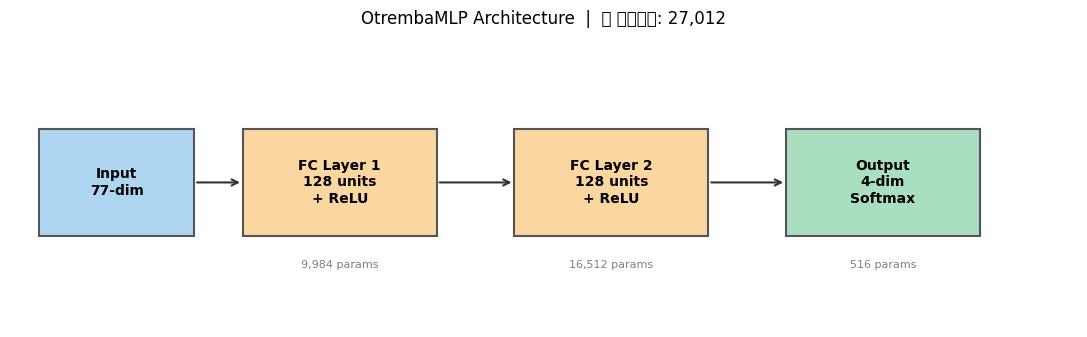

In [2]:
# OtrembaMLP 아키텍처 다이어그램
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.5)

# 박스 정의: (x, y, width, height, label, color)
boxes = [
    (0.3, 1.1, 1.6, 1.3, 'Input\n77-dim', '#AED6F1'),
    (2.4, 1.1, 2.0, 1.3, 'FC Layer 1\n128 units\n+ ReLU', '#FAD7A0'),
    (5.2, 1.1, 2.0, 1.3, 'FC Layer 2\n128 units\n+ ReLU', '#FAD7A0'),
    (8.0, 1.1, 2.0, 1.3, 'Output\n4-dim\nSoftmax', '#A9DFBF'),
]

for x, y, w, h, text, color in boxes:
    rect = plt.Rectangle((x, y), w, h, linewidth=1.5,
                          edgecolor='#555', facecolor=color, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold', zorder=3)

# 파라미터 수 라벨
param_labels = ['', '9,984 params', '16,512 params', '516 params']
xs = [0.3, 2.4, 5.2, 8.0]
ws = [1.6, 2.0, 2.0, 2.0]
for i, (x, w, lbl) in enumerate(zip(xs, ws, param_labels)):
    if lbl:
        ax.text(x + w/2, 0.75, lbl, ha='center', va='center', fontsize=8, color='gray')

# 화살표
arrow_xs = [(1.9, 2.4), (4.4, 5.2), (7.2, 8.0)]
for (x1, x2) in arrow_xs:
    ax.annotate('', xy=(x2, 1.75), xytext=(x1, 1.75),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5), zorder=1)

ax.axis('off')
ax.set_title('OtrembaMLP Architecture  |  총 파라미터: 27,012', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## 3. 77차원 Feature 분해

Model B의 77차원 입력 벡터는 다음 그룹으로 구성된다.

| 그룹 | 차원 | 내용 |
|------|-----:|------|
| 연속 피처 | 15 | 구속, 회전수, 무브먼트, 플레이트 위치 등 StandardScaler 정규화 |
| pitch_type | 17 | 구종 one-hot (FF/SI/SL/CH/FC/ST/CU/FS/KC/SV/FA/KN/EP/FO/SC/CS/PO) |
| zone | 14 | 투구 위치 zone 1~14 one-hot |
| balls | 4 | 볼카운트 (0~3) one-hot |
| strikes | 3 | 스트라이크 카운트 (0~2) one-hot |
| outs | 3 | 아웃카운트 (0~2) one-hot |
| base | 8 | 주자 상황 (1루/2루/3루 조합) one-hot |
| stand | 2 | 타자 좌/우 one-hot |
| p_throws | 2 | 투수 좌/우 one-hot |
| inning | 9 | 이닝 1~9 one-hot (연장은 9로 클리핑) |
| **합계** | **77** | |

**Model C(87차원)와의 차이**: inning(9) 대신 result(10) + hit_location(9)이 포함된다.
result와 hit_location은 마지막 pitch에서 0 마스킹(sub-token mask)으로 데이터 누수를 방지한다.

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1801947655.py:39: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1801947655.py:39: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1801947655.py:39: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1801947655.py:39: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1801947655.py:39: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1801947655.py:39: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(

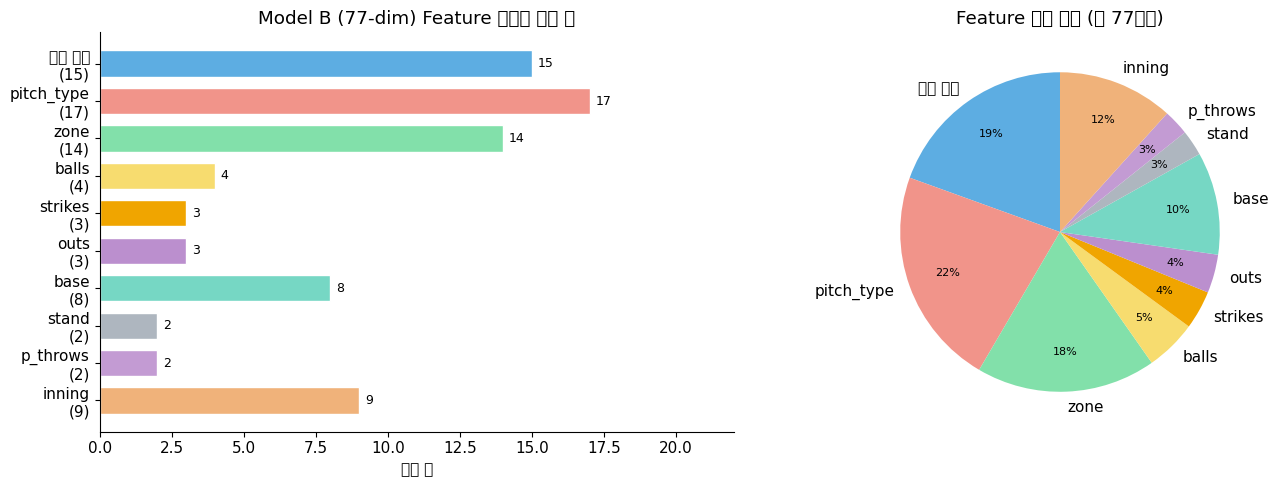

총 차원: 77


In [3]:
# 77차원 Feature 그룹 시각화
groups = [
    ('연속 피처', 15, '#5DADE2'),
    ('pitch_type', 17, '#F1948A'),
    ('zone', 14, '#82E0AA'),
    ('balls', 4, '#F7DC6F'),
    ('strikes', 3, '#F0A500'),
    ('outs', 3, '#BB8FCE'),
    ('base', 8, '#76D7C4'),
    ('stand', 2, '#AEB6BF'),
    ('p_throws', 2, '#C39BD3'),
    ('inning', 9, '#F0B27A'),
]

labels = [f'{g[0]}\n({g[1]})' for g in groups]
sizes = [g[1] for g in groups]
colors = [g[2] for g in groups]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 수평 막대 그래프
bars = axes[0].barh(labels[::-1], sizes[::-1], color=colors[::-1], edgecolor='white', height=0.7)
for bar, size in zip(bars, sizes[::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(size), va='center', fontsize=9)
axes[0].set_xlabel('차원 수')
axes[0].set_title('Model B (77-dim) Feature 그룹별 차원 수')
axes[0].set_xlim(0, 22)

# 오른쪽: 파이 차트
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=[g[0] for g in groups], colors=colors,
    autopct='%1.0f%%', startangle=90, pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(8)
axes[1].set_title('Feature 그룹 비율 (총 77차원)')

plt.tight_layout()
plt.show()

print(f'총 차원: {sum(sizes)}')

## 4. 데이터 처리 흐름

```
Statcast 원본 (1,534,286 rows)
    ↓ 전처리 (scripts/04_preprocess.py)
    ↓  • deprecated 컬럼 제거
    ↓  • truncated_pa 제거 (660건)
    ↓  • NaN pitch_type 제거
정제 데이터 (1,488,976 rows, -3.0%)
    ↓ Feature 엔지니어링
    ↓  • 연속 피처 15개 → StandardScaler 정규화
    ↓  • 카테고리 → one-hot 인코딩
    ↓  • 4-class 라벨 매핑
    ↓ 시간순 train/val/test 분할 (날짜 겹침 없음)
model_b_train.pt  (749,880 rows)
model_b_val.pt    (385,320 rows)
model_b_test.pt   (353,776 rows)
```

`PitchPointDataset`은 전체 데이터를 메모리에 올리는 **eager loading** 방식을 사용한다.
77차원 × 749,880 rows × float32 ≈ 220 MB 로 메모리 부담이 없다.

In [4]:
# 학습 데이터 로드 및 기본 통계
train_data = torch.load('../data/processed/model_b_train.pt', weights_only=False)
val_data = torch.load('../data/processed/model_b_val.pt', weights_only=False)

vecs_train = train_data['vectors']
labels_train = train_data['labels']
vecs_val = val_data['vectors']
labels_val = val_data['labels']

print('=== 데이터 Shape ===')
print(f'Train vectors : {vecs_train.shape}  ({vecs_train.nbytes / 1e6:.1f} MB)')
print(f'Train labels  : {labels_train.shape}')
print(f'Val vectors   : {vecs_val.shape}   ({vecs_val.nbytes / 1e6:.1f} MB)')

print('\n=== 연속 피처 통계 (앞 15차원, 정규화 후) ===')
cont = vecs_train[:, :15]
print(f'평균: {cont.mean(axis=0)[:5].round(3)}  ...  (첫 5개)')
print(f'표준편차: {cont.std(axis=0)[:5].round(3)}  ...  (첫 5개)')
print('→ 정규화 적용됨 (평균≈0, 표준편차≈1)')

=== 데이터 Shape ===
Train vectors : (749880, 77)  (231.0 MB)
Train labels  : (749880,)
Val vectors   : (385320, 77)   (118.7 MB)

=== 연속 피처 통계 (앞 15차원, 정규화 후) ===
평균: [ 0. -0. -0.  0. -0.]  ...  (첫 5개)
표준편차: [1. 1. 1. 1. 1.]  ...  (첫 5개)
→ 정규화 적용됨 (평균≈0, 표준편차≈1)


C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1537905616.py:46: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1537905616.py:46: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1537905616.py:46: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1537905616.py:46: UserWarning: Glyph 48289 (\N{HANGUL SYLLABLE BEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1537905616.py:46: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1537905616.py:46: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from fo

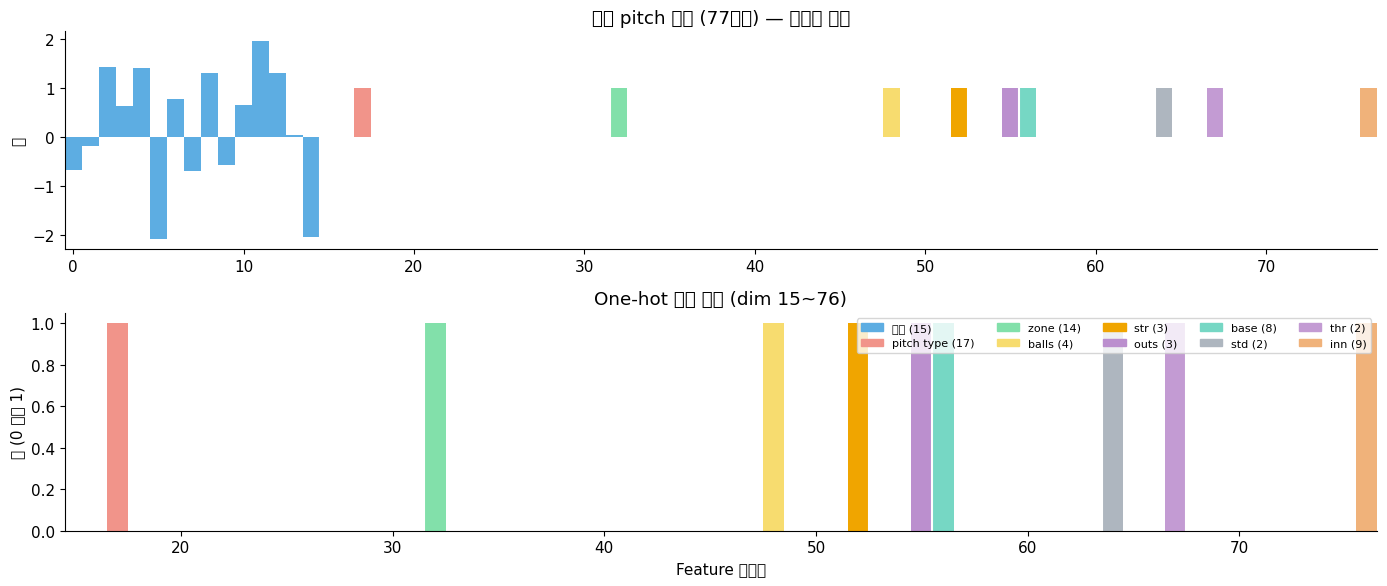

In [5]:
# 샘플 벡터 시각화 — 첫 번째 pitch의 77차원 값
sample_vec = vecs_train[0]

# 그룹 경계선 위치
group_boundaries = [0, 15, 32, 46, 50, 53, 56, 64, 66, 68, 77]
group_names = ['연속\n(15)', 'pitch\ntype\n(17)', 'zone\n(14)',
               'balls\n(4)', 'str\n(3)', 'outs\n(3)',
               'base\n(8)', 'std\n(2)', 'thr\n(2)', 'inn\n(9)']
group_colors = ['#5DADE2','#F1948A','#82E0AA','#F7DC6F','#F0A500',
                '#BB8FCE','#76D7C4','#AEB6BF','#C39BD3','#F0B27A']

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# 위: 전체 77차원 막대 (그룹별 색상)
bar_colors = []
for i, (start, end, c) in enumerate(zip(group_boundaries[:-1], group_boundaries[1:], group_colors)):
    bar_colors.extend([c] * (end - start))

axes[0].bar(range(77), sample_vec, color=bar_colors, width=1.0, edgecolor='none')
axes[0].set_xlim(-0.5, 76.5)
axes[0].set_ylabel('값')
axes[0].set_title('샘플 pitch 벡터 (77차원) — 그룹별 색상')

# 그룹 경계 수직선 + 라벨
for start, name in zip(group_boundaries[:-1], group_names):
    if start > 0:
        axes[0].axvline(start - 0.5, color='white', lw=1.5)

# 아래: one-hot 부분만 확대 (dim 15~77)
axes[1].bar(range(15, 77), sample_vec[15:], color=bar_colors[15:], width=1.0, edgecolor='none')
axes[1].set_xlim(14.5, 76.5)
axes[1].set_ylabel('값 (0 또는 1)')
axes[1].set_xlabel('Feature 인덱스')
axes[1].set_title('One-hot 영역 확대 (dim 15~76)')

# 그룹 경계
for start in group_boundaries[1:-1]:
    if start > 15:
        axes[1].axvline(start - 0.5, color='white', lw=1.5)

# 범례
patches = [mpatches.Patch(color=c, label=n.replace('\n', ' ').strip())
           for c, n in zip(group_colors, group_names)]
axes[1].legend(handles=patches, loc='upper right', ncol=5, fontsize=8)

plt.tight_layout()
plt.show()

## 5. 4-class 라벨 정의 및 분포

Otremba 2022 논문의 4-class 매핑:

| 클래스 | 이름 | 포함 description |
|--------|------|------------------|
| 0 | Ball | ball, blocked_ball, automatic_ball, pitchout, hit_by_pitch |
| 1 | Strike | called_strike, swinging_strike, swinging_strike_blocked, foul_tip, missed_bunt, automatic_strike, bunt_foul_tip |
| 2 | Foul | foul, foul_bunt |
| 3 | InPlay | hit_into_play |

**hit_by_pitch → Ball**: 논문이 사구를 볼과 같이 처리하는 방식을 그대로 따른다.

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1373143537.py:25: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1373143537.py:25: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1373143537.py:25: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1373143537.py:25: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1373143537.py:25: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\1373143537.py:25: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font

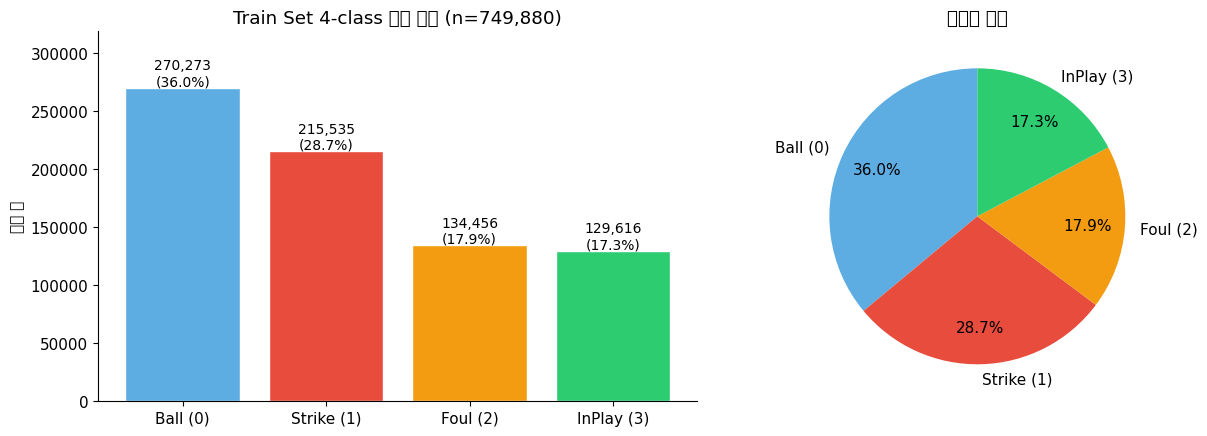

=== 클래스별 통계 ===
  Ball (0): 270,273 (36.0%)
  Strike (1): 215,535 (28.7%)
  Foul (2): 134,456 (17.9%)
  InPlay (3): 129,616 (17.3%)

→ Ball이 가장 많음 (36.0%)
→ 무작위 분류기(Ball만 예측) 정확도: 36.0%


In [6]:
# 4-class 라벨 분포 시각화
class_names = ['Ball (0)', 'Strike (1)', 'Foul (2)', 'InPlay (3)']
class_colors = ['#5DADE2', '#E74C3C', '#F39C12', '#2ECC71']

# Train set 라벨 카운트
unique, counts = np.unique(labels_train, return_counts=True)
total = counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 막대 그래프
bars = axes[0].bar(class_names, counts, color=class_colors, edgecolor='white')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{cnt:,}\n({cnt/total*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_ylabel('샘플 수')
axes[0].set_title('Train Set 4-class 라벨 분포 (n=749,880)')
axes[0].set_ylim(0, max(counts) * 1.18)

# 파이 차트
axes[1].pie(counts, labels=class_names, colors=class_colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75)
axes[1].set_title('클래스 비율')

plt.tight_layout()
plt.show()

print('=== 클래스별 통계 ===')
for i, (name, cnt) in enumerate(zip(class_names, counts)):
    print(f'  {name}: {cnt:,} ({cnt/total*100:.1f}%)')
print(f'\n→ Ball이 가장 많음 ({counts[0]/total*100:.1f}%)')
print(f'→ 무작위 분류기(Ball만 예측) 정확도: {counts[0]/total*100:.1f}%')

## 6. 모델 코드 Walkthrough

`src/models/otremba_mlp.py`의 핵심 구조:

```python
class OtrembaMLP(TransitionModel):
    def __init__(self, input_dim=77, hidden_dim=128, n_classes=4, dropout=0.0):
        layers = [
            nn.Linear(input_dim, hidden_dim),  # 77 → 128
            nn.ReLU(),
            # dropout > 0이면 Dropout 삽입
            nn.Linear(hidden_dim, hidden_dim),  # 128 → 128
            nn.ReLU(),
            nn.Linear(hidden_dim, n_classes),   # 128 → 4
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x) -> Tensor:  # raw logits (batch, 4)
        return self.net(x)

    def predict_proba(self, x) -> Tensor:  # softmax (batch, 4)
        return torch.softmax(self.forward(x), dim=-1)
```

`TransitionModel` ABC에서 상속하여 `num_classes()`, `model_name()`, `predict_proba()`를 구현한다.
학습 시에는 `forward()`의 raw logits에 `F.cross_entropy()`를 적용하고,
추론 시에는 `predict_proba()`로 확률값을 반환한다.

In [7]:
# 모델 구조 확인
model = OtrembaMLP(input_dim=77, hidden_dim=128, n_classes=4)
print(model)

n_params = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n총 파라미터: {n_params:,}')
print(f'학습 가능 파라미터: {n_train:,}')

# Layer별 파라미터
print('\n=== Layer별 파라미터 수 ===')
for name, param in model.named_parameters():
    print(f'  {name:30s}: {param.numel():,}  shape={tuple(param.shape)}')

OtrembaMLP(
  (net): Sequential(
    (0): Linear(in_features=77, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

총 파라미터: 27,012
학습 가능 파라미터: 27,012

=== Layer별 파라미터 수 ===
  net.0.weight                  : 9,856  shape=(128, 77)
  net.0.bias                    : 128  shape=(128,)
  net.2.weight                  : 16,384  shape=(128, 128)
  net.2.bias                    : 128  shape=(128,)
  net.4.weight                  : 512  shape=(4, 128)
  net.4.bias                    : 4  shape=(4,)


## 7. 학습 설정

| 항목 | 값 | 이유 |
|------|-----|------|
| Optimizer | AdamW | weight decay 지원, 기본 선택 |
| Learning Rate | 1e-3 | AdamW 표준 시작값 |
| Weight Decay | 1e-5 | 과적합 억제 |
| Batch Size | 256 | GPU 메모리 여유 + 빠른 수렴 |
| Scheduler | CosineAnnealingLR | 전체 step에 걸쳐 LR 감소 |
| Max Epochs | 200 | Early stopping이 실질적 종료 결정 |
| Early Stopping | patience=10 | val loss 기준 |
| Loss | CrossEntropyLoss | 4-class 분류 |
| Device | CUDA (RTX 4070) | |

**Epoch당 소요 시간**: ~23초 (2,930 batches × 256 samples)

**학습 스크립트**: `scripts/08_train_model_b.py`
**W&B Run**: [model_b_full_v1](https://wandb.ai/pitcheezy/transition-models/runs/bspnzo7m)

## 8. 결과

| Epoch | Train Loss | Val Loss | Val Acc |
|-------|-----------|---------|--------|
| 1 | 0.9066 | 0.8861 | — |
| 3 | 0.8739 | 0.8746 | — |
| 7 | 0.8662 | 0.8734 | — |
| **10 (Best)** | **0.8631** | **0.8730** | — |
| 16 | 0.8581 | 0.8738 | — |
| 20 (조기 종료) | 0.8556 | 0.8779 | 60.6% |

- **Best val loss: 0.8730** (epoch 10)
- **Final val accuracy: 60.6%** (train: 61.8%)
- **Train-val gap: ~0.02** → 과적합 거의 없음
- **조기 종료**: epoch 20 (patience=10)
- **총 학습 시간**: ~8분
- **Baseline 대비**: Ball-only 기준(~36.7%) 대비 **+24pp** 향상

In [8]:
# Best checkpoint 로드 + Sample Prediction
checkpoint_path = '../outputs/checkpoints/model_b_full_v1_best.pt'

ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model = OtrembaMLP()
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'Best checkpoint: epoch {ckpt["epoch"]+1}')
print(f'Val metrics: {ckpt["val_metrics"]}')

# 처음 10개 샘플 예측
sample_x = torch.from_numpy(vecs_train[:10]).float()
sample_y = labels_train[:10]

with torch.no_grad():
    proba = model.predict_proba(sample_x).numpy()

print('\n=== 처음 10개 샘플 예측 확률 ===')
print(f'{"":3s}  {"Ball":>8s}  {"Strike":>8s}  {"Foul":>8s}  {"InPlay":>8s}  {"예측":>7s}  {"정답":>5s}')
class_map = {0: 'Ball', 1: 'Strike', 2: 'Foul', 3: 'InPlay'}
for i, (prob, true_lbl) in enumerate(zip(proba, sample_y)):
    pred = prob.argmax()
    match = '✓' if pred == true_lbl else '✗'
    print(f'{i+1:3d}  {prob[0]:8.3f}  {prob[1]:8.3f}  {prob[2]:8.3f}  {prob[3]:8.3f}  '
          f'{class_map[pred]:>7s}  {class_map[true_lbl]:>5s} {match}')

Best checkpoint: epoch 10
Val metrics: {'loss': 0.8729671512150353, 'accuracy': 0.6085340928034003}

=== 처음 10개 샘플 예측 확률 ===
         Ball    Strike      Foul    InPlay       예측     정답
  1     0.241     0.494     0.152     0.113   Strike  Strike ✓
  2     0.509     0.116     0.237     0.139     Ball   Ball ✓
  3     0.145     0.782     0.045     0.028   Strike  Strike ✓
  4     0.017     0.503     0.333     0.146   Strike   Foul ✗
  5     0.636     0.211     0.092     0.061     Ball   Ball ✓
  6     0.478     0.279     0.179     0.064     Ball  InPlay ✗
  7     0.766     0.229     0.005     0.000     Ball   Ball ✓
  8     0.135     0.395     0.296     0.174   Strike  Strike ✓
  9     0.060     0.433     0.285     0.223   Strike   Foul ✗
 10     0.966     0.032     0.001     0.001     Ball   Ball ✓


C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\4229006833.py:24: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\4229006833.py:24: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\4229006833.py:24: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\4229006833.py:24: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\4229006833.py:24: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_1880\4229006833.py:24: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from fo

C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: Use

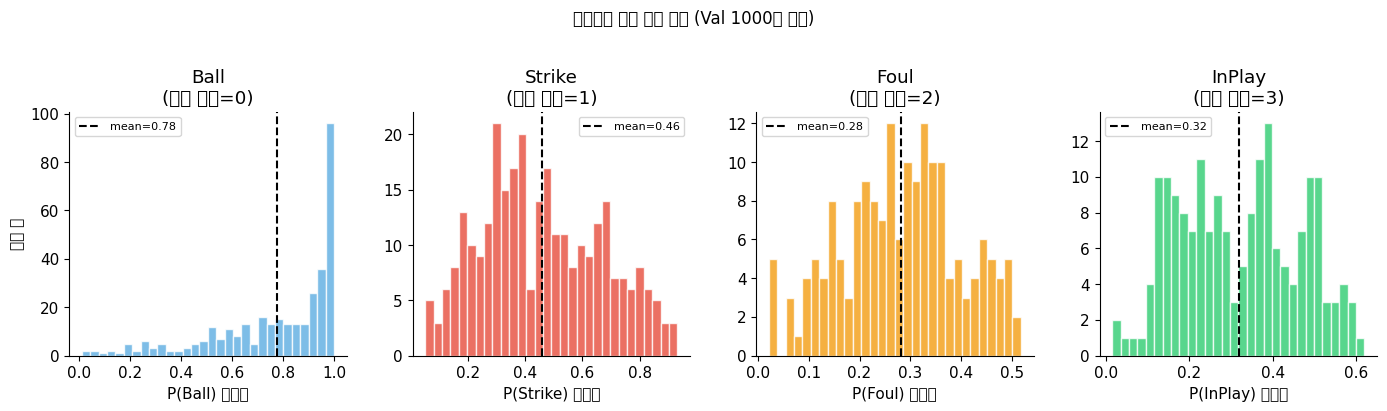

In [9]:
# 예측 확률 분포 시각화 (Val set 1000개 샘플)
sample_val_x = torch.from_numpy(vecs_val[:1000]).float()
sample_val_y = labels_val[:1000]

with torch.no_grad():
    proba_val = model.predict_proba(sample_val_x).numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)
class_colors_list = ['#5DADE2', '#E74C3C', '#F39C12', '#2ECC71']

for i, (name, color) in enumerate(zip(['Ball', 'Strike', 'Foul', 'InPlay'], class_colors_list)):
    # 해당 클래스에 속하는 샘플들의 예측 확률 분포
    mask = sample_val_y == i
    if mask.sum() > 0:
        axes[i].hist(proba_val[mask, i], bins=30, color=color, alpha=0.8, edgecolor='white')
        axes[i].axvline(proba_val[mask, i].mean(), color='black', ls='--', lw=1.5,
                        label=f'mean={proba_val[mask, i].mean():.2f}')
    axes[i].set_title(f'{name}\n(실제 라벨={i})')
    axes[i].set_xlabel(f'P({name}) 예측값')
    axes[i].legend(fontsize=8)

axes[0].set_ylabel('샘플 수')
plt.suptitle('클래스별 예측 확률 분포 (Val 1000개 샘플)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 9. 한계점

### 9.1 단일 투구 기반 (No Sequence)

Model B는 **현재 투구 하나의 물리량**만 입력으로 받는다.
타자가 앞선 3개 투구에서 연속 파울을 쳤다거나, 투수가 이번 이닝에서
구속이 4km/h 떨어졌다는 정보를 전혀 활용하지 못한다.

### 9.2 Foul / Strike 구분의 전략적 의미

4-class에서 Foul과 Strike를 구분하지만, 0-2 카운트에서의 Foul은
실질적으로 Strike와 동일한 게임 상태를 유지한다.
반면 2-스트라이크 상황에서의 Foul은 타자에게 유리한 점도 있다.
이 미묘한 전략적 차이가 모델에 반영되지 않는다.

### 9.3 Class Imbalance 미처리

Ball(약 34%) > Strike(약 27%) > Foul(약 18%) > InPlay(약 18%) 불균형이 있음에도
현재 class weighting 없이 학습했다.

### 9.4 Continuous Output 없음

공의 궤적, 발사각도, 타구 속도 등의 연속값 예측이 없어 MDP 상태 전이의
완전한 기술이 불가능하다. Model C는 5차원 연속 출력을 갖는다.

---

*다음 노트북: [04_model_c_mit_sloan_2025.ipynb](04_model_c_mit_sloan_2025.ipynb)*